In [1]:
import pandas as pd

In [3]:
df = pd.read_csv("tuning_runs.csv")
check_df = pd.read_csv("check_tuning_runs.csv")

In [5]:
check_df

,run_name,loss_fn,ckpt_pt,pretrained,labs_model,weight_decay,learning_rate,wandb_path,epoch,val_loss,...,val_Pleural Effusion_true_cxr_acc_at_10,val_label_precision_at_1,val_label_precision_at_5,val_label_precision_at_10,val_label_acc_at_1,val_label_acc_at_5,val_label_acc_at_10,val_true_cxr_acc_at_1,val_true_cxr_acc_at_5,val_true_cxr_acc_at_10
0,20240430_013053_9889,symile,/gpfs/scratch/as16583/ckpts/cxr_prediction/202...,True,mlp,1.00,0.0005,https://wandb.ai/rajesh-lab/symile/runs/41uit3ng,0,5.242456,...,0.0,0.04,0.024,0.024,0.04,0.12,0.20,0.04,0.04,0.08
1,20240430_013053_9889,symile,/gpfs/scratch/as16583/ckpts/cxr_prediction/202...,True,mlp,1.00,0.0005,https://wandb.ai/rajesh-lab/symile/runs/41uit3ng,1,4.777665,...,0.4,0.04,0.088,0.064,0.04,0.40,0.44,0.00,0.24,0.28
2,20240430_013053_9889,symile,/gpfs/scratch/as16583/ckpts/cxr_prediction/202...,True,mlp,1.00,0.0005,https://wandb.ai/rajesh-lab/symile/runs/41uit3ng,2,4.419787,...,0.4,0.12,0.088,0.076,0.12,0.36,0.64,0.12,0.20,0.32
3,20240430_013053_9889,symile,/gpfs/scratch/as16583/ckpts/cxr_prediction/202...,True,mlp,1.00,0.0005,https://wandb.ai/rajesh-lab/symile/runs/41uit3ng,3,4.447899,...,0.4,0.16,0.088,0.076,0.16,0.36,0.56,0.04,0.24,0.32
4,20240430_013053_9889,symile,/gpfs/scratch/as16583/ckpts/cxr_prediction/202...,True,mlp,1.00,0.0005,https://wandb.ai/rajesh-lab/symile/runs/41uit3ng,4,5.078539,...,0.2,0.20,0.072,0.076,0.20,0.32,0.64,0.12,0.20,0.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,20240430_013943_4965,clip,/gpfs/scratch/as16583/ckpts/cxr_prediction/202...,True,ftt,0.01,0.0005,https://wandb.ai/rajesh-lab/symile/runs/m1hcu5b7,45,34.944954,...,0.2,0.16,0.096,0.080,0.16,0.36,0.60,0.12,0.28,0.36
96,20240430_013943_4965,clip,/gpfs/scratch/as16583/ckpts/cxr_prediction/202...,True,ftt,0.01,0.0005,https://wandb.ai/rajesh-lab/symile/runs/m1hcu5b7,46,35.080467,...,0.0,0.08,0.072,0.060,0.08,0.32,0.48,0.08,0.20,0.28
97,20240430_013943_4965,clip,/gpfs/scratch/as16583/ckpts/cxr_prediction/202...,True,ftt,0.01,0.0005,https://wandb.ai/rajesh-lab/symile/runs/m1hcu5b7,47,35.694454,...,0.4,0.16,0.072,0.068,0.16,0.36,0.56,0.12,0.28,0.40
98,20240430_013943_4965,clip,/gpfs/scratch/as16583/ckpts/cxr_prediction/202...,True,ftt,0.01,0.0005,https://wandb.ai/rajesh-lab/symile/runs/m1hcu5b7,48,36.350948,...,0.0,0.16,0.096,0.084,0.16,0.40,0.60,0.16,0.24,0.36


In [5]:
symile_df = df[df["loss_fn"] == "symile"]
clip_df = df[df["loss_fn"] == "clip"]

In [8]:
df.columns

Index(['run_name', 'loss_fn', 'ckpt_pt', 'pretrained', 'labs_model',
       'weight_decay', 'learning_rate', 'wandb_path', 'epoch', 'val_loss',
       'val_Atelectasis_precision_at_1', 'val_Atelectasis_precision_at_5',
       'val_Atelectasis_precision_at_10', 'val_Cardiomegaly_precision_at_1',
       'val_Cardiomegaly_precision_at_5', 'val_Cardiomegaly_precision_at_10',
       'val_Consolidation_precision_at_1', 'val_Consolidation_precision_at_5',
       'val_Consolidation_precision_at_10', 'val_Edema_precision_at_1',
       'val_Edema_precision_at_5', 'val_Edema_precision_at_10',
       'val_Pleural Effusion_precision_at_1',
       'val_Pleural Effusion_precision_at_5',
       'val_Pleural Effusion_precision_at_10', 'val_Atelectasis_acc_at_1',
       'val_Atelectasis_acc_at_5', 'val_Atelectasis_acc_at_10',
       'val_Cardiomegaly_acc_at_1', 'val_Cardiomegaly_acc_at_5',
       'val_Cardiomegaly_acc_at_10', 'val_Consolidation_acc_at_1',
       'val_Consolidation_acc_at_5', 'val_Consol

In [7]:
idx = df.groupby(['loss_fn'])['val_true_cxr_acc_at_1'].idxmax()
result_df = df.loc[idx]
result_df[['loss_fn', 'pretrained', 'labs_model',
       'weight_decay', 'learning_rate', 'epoch', 'val_loss',
       'val_true_cxr_acc_at_1', 'val_true_cxr_acc_at_5', 'val_true_cxr_acc_at_10',
       'val_label_acc_at_1', 'val_label_acc_at_5', 'val_label_acc_at_10',
       'val_label_precision_at_1', 'val_label_precision_at_5', 'val_label_precision_at_10',
        'run_name', 'ckpt_pt', 'wandb_path']]

,loss_fn,pretrained,labs_model,weight_decay,learning_rate,epoch,val_loss,val_true_cxr_acc_at_1,val_true_cxr_acc_at_5,val_true_cxr_acc_at_10,val_label_acc_at_1,val_label_acc_at_5,val_label_acc_at_10,val_label_precision_at_1,val_label_precision_at_5,val_label_precision_at_10,run_name,ckpt_pt,wandb_path
10589,clip,True,ftt,0.01,0.0005,89,57.040833,0.24,0.44,0.44,0.24,0.60,0.64,0.24,0.152,0.088,20240428_055449_8115,/gpfs/scratch/as16583/ckpts/cxr_prediction/202...,https://wandb.ai/rajesh-lab/symile/runs/ec9b5ruf
2792,symile,True,mlp,1.00,0.0005,92,6.929059,0.32,0.52,0.68,0.36,0.64,0.80,0.36,0.128,0.120,20240427_222533_3724,/gpfs/scratch/as16583/ckpts/cxr_prediction/202...,https://wandb.ai/rajesh-lab/symile/runs/rjhbzr7p


In [8]:
idx = check_df.groupby(['loss_fn'])['val_true_cxr_acc_at_1'].idxmax()
result_df = check_df.loc[idx]
result_df[['loss_fn', 'pretrained', 'labs_model',
       'weight_decay', 'learning_rate', 'epoch', 'val_loss',
       'val_true_cxr_acc_at_1', 'val_true_cxr_acc_at_5', 'val_true_cxr_acc_at_10',
       'val_label_acc_at_1', 'val_label_acc_at_5', 'val_label_acc_at_10',
       'val_label_precision_at_1', 'val_label_precision_at_5', 'val_label_precision_at_10',
        'run_name', 'ckpt_pt', 'wandb_path']]

,loss_fn,pretrained,labs_model,weight_decay,learning_rate,epoch,val_loss,val_true_cxr_acc_at_1,val_true_cxr_acc_at_5,val_true_cxr_acc_at_10,val_label_acc_at_1,val_label_acc_at_5,val_label_acc_at_10,val_label_precision_at_1,val_label_precision_at_5,val_label_precision_at_10,run_name,ckpt_pt,wandb_path
78,clip,True,ftt,0.01,0.0005,28,20.352303,0.2,0.24,0.32,0.2,0.32,0.44,0.2,0.088,0.056,20240430_013943_4965,/gpfs/scratch/as16583/ckpts/cxr_prediction/202...,https://wandb.ai/rajesh-lab/symile/runs/m1hcu5b7
49,symile,True,mlp,1.00,0.0005,49,7.848659,0.2,0.52,0.64,0.2,0.64,0.84,0.2,0.136,0.112,20240430_013053_9889,/gpfs/scratch/as16583/ckpts/cxr_prediction/202...,https://wandb.ai/rajesh-lab/symile/runs/41uit3ng


In [6]:
df[(df['run_name'] == "20240427_222533_3724") & (df['weight_decay'] == 1.0) & (df['learning_rate'] == 0.0005) & (df['epoch'] == 92)][['loss_fn', 'pretrained', 'labs_model',
       'weight_decay', 'learning_rate', 'epoch', 'val_loss',
       'val_true_cxr_acc_at_1', 'val_true_cxr_acc_at_5', 'val_true_cxr_acc_at_10',
       'val_label_acc_at_1', 'val_label_acc_at_5', 'val_label_acc_at_10',
       'val_label_precision_at_1', 'val_label_precision_at_5', 'val_label_precision_at_10',
        'run_name', 'ckpt_pt', 'wandb_path']]

,loss_fn,pretrained,labs_model,weight_decay,learning_rate,epoch,val_loss,val_true_cxr_acc_at_1,val_true_cxr_acc_at_5,val_true_cxr_acc_at_10,val_label_acc_at_1,val_label_acc_at_5,val_label_acc_at_10,val_label_precision_at_1,val_label_precision_at_5,val_label_precision_at_10,run_name,ckpt_pt,wandb_path
2792,symile,True,mlp,1.0,0.0005,92,6.929059,0.32,0.52,0.68,0.36,0.64,0.8,0.36,0.128,0.12,20240427_222533_3724,/gpfs/scratch/as16583/ckpts/cxr_prediction/202...,https://wandb.ai/rajesh-lab/symile/runs/rjhbzr7p


<Axes: xlabel='learning_rate', ylabel='val_label_acc_at_1'>

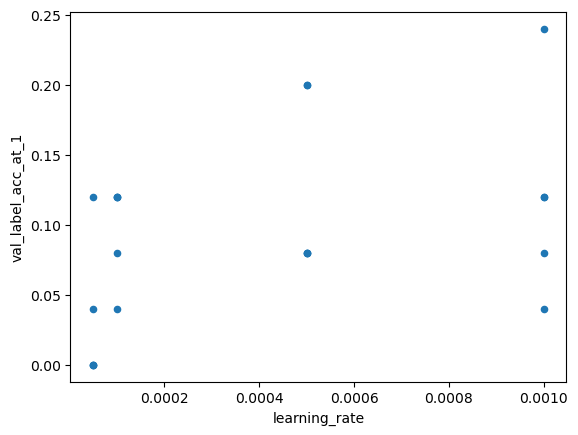

In [10]:
# plot validation loss on y axis and learning rate on the x axis
df = result_df[['learning_rate', 'weight_decay', 'val_loss', 'val_label_acc_at_1']]
df.plot.scatter(x='learning_rate', y='val_label_acc_at_1')

## symile

In [10]:
columns_to_show = ['run_name', 'loss_fn', 'ckpt_pt', 'weight_decay', 'learning_rate',
                   'wandb_path', 'val_loss', 'epoch',
                   'val_label_precision_at_1', 'val_label_precision_at_5', 'val_label_precision_at_10',
                   'val_label_acc_at_1', 'val_label_acc_at_5', 'val_label_acc_at_10',
                   'val_true_cxr_acc_at_1', 'val_true_cxr_acc_at_5', 'val_true_cxr_acc_at_10']
symile_df = symile_df[columns_to_show]
symile_df

,run_name,loss_fn,ckpt_pt,weight_decay,learning_rate,wandb_path,val_loss,epoch,val_label_precision_at_1,val_label_precision_at_5,val_label_precision_at_10,val_label_acc_at_1,val_label_acc_at_5,val_label_acc_at_10,val_true_cxr_acc_at_1,val_true_cxr_acc_at_5,val_true_cxr_acc_at_10
0,20240423_235202_3604,symile,/gpfs/scratch/as16583/ckpts/cxr_prediction/202...,0.0,0.00100,https://wandb.ai/rajesh-lab/symile/runs/8uet9xo0,5.578375,0,0.00,0.000,0.024,0.00,0.00,0.24,0.00,0.00,0.08
1,20240423_235202_3604,symile,/gpfs/scratch/as16583/ckpts/cxr_prediction/202...,0.0,0.00100,https://wandb.ai/rajesh-lab/symile/runs/8uet9xo0,5.381792,1,0.04,0.056,0.076,0.04,0.28,0.60,0.00,0.04,0.20
2,20240423_235202_3604,symile,/gpfs/scratch/as16583/ckpts/cxr_prediction/202...,0.0,0.00100,https://wandb.ai/rajesh-lab/symile/runs/8uet9xo0,5.302138,2,0.00,0.080,0.092,0.00,0.28,0.56,0.00,0.08,0.28
3,20240423_235202_3604,symile,/gpfs/scratch/as16583/ckpts/cxr_prediction/202...,0.0,0.00100,https://wandb.ai/rajesh-lab/symile/runs/8uet9xo0,5.293000,3,0.00,0.088,0.092,0.00,0.32,0.64,0.00,0.16,0.28
4,20240423_235202_3604,symile,/gpfs/scratch/as16583/ckpts/cxr_prediction/202...,0.0,0.00100,https://wandb.ai/rajesh-lab/symile/runs/8uet9xo0,5.299915,4,0.12,0.080,0.080,0.12,0.40,0.52,0.04,0.08,0.24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,20240424_040713_0007,symile,/gpfs/scratch/as16583/ckpts/cxr_prediction/202...,0.1,0.00005,https://wandb.ai/rajesh-lab/symile/runs/y2an8oof,8.709339,45,0.08,0.080,0.068,0.08,0.36,0.48,0.00,0.16,0.32
996,20240424_040713_0007,symile,/gpfs/scratch/as16583/ckpts/cxr_prediction/202...,0.1,0.00005,https://wandb.ai/rajesh-lab/symile/runs/y2an8oof,9.066010,46,0.04,0.064,0.072,0.04,0.28,0.48,0.00,0.16,0.32
997,20240424_040713_0007,symile,/gpfs/scratch/as16583/ckpts/cxr_prediction/202...,0.1,0.00005,https://wandb.ai/rajesh-lab/symile/runs/y2an8oof,8.488188,47,0.04,0.016,0.016,0.04,0.08,0.16,0.00,0.00,0.08
998,20240424_040713_0007,symile,/gpfs/scratch/as16583/ckpts/cxr_prediction/202...,0.1,0.00005,https://wandb.ai/rajesh-lab/symile/runs/y2an8oof,8.494869,48,0.08,0.072,0.076,0.08,0.32,0.56,0.04,0.12,0.28


In [16]:
# VAL LOSS, ASCENDING TRUE
symile_df.sort_values(by="val_loss", ascending=True).head(1)

,run_name,loss_fn,ckpt_pt,weight_decay,learning_rate,wandb_path,val_loss,epoch,val_label_precision_at_1,val_label_precision_at_5,val_label_precision_at_10,val_label_acc_at_1,val_label_acc_at_5,val_label_acc_at_10,val_true_cxr_acc_at_1,val_true_cxr_acc_at_5,val_true_cxr_acc_at_10
866,20240424_033209_7904,symile,/gpfs/scratch/as16583/ckpts/cxr_prediction/202...,0.1,0.0005,https://wandb.ai/rajesh-lab/symile/runs/wht6emoh,4.475124,16,0.2,0.08,0.068,0.2,0.4,0.56,0.16,0.28,0.48


## clip

In [17]:
clip_df = clip_df[columns_to_show]
clip_df

,run_name,loss_fn,ckpt_pt,weight_decay,learning_rate,wandb_path,val_loss,epoch,val_label_precision_at_1,val_label_precision_at_5,val_label_precision_at_10,val_label_acc_at_1,val_label_acc_at_5,val_label_acc_at_10,val_true_cxr_acc_at_1,val_true_cxr_acc_at_5,val_true_cxr_acc_at_10
1000,20240424_040914_4926,clip,/gpfs/scratch/as16583/ckpts/cxr_prediction/202...,0.0,0.00100,https://wandb.ai/rajesh-lab/symile/runs/9b8dmujy,16.457558,0,0.00,0.016,0.024,0.00,0.08,0.24,0.00,0.04,0.04
1001,20240424_040914_4926,clip,/gpfs/scratch/as16583/ckpts/cxr_prediction/202...,0.0,0.00100,https://wandb.ai/rajesh-lab/symile/runs/9b8dmujy,16.385851,1,0.12,0.080,0.044,0.12,0.40,0.44,0.04,0.12,0.12
1002,20240424_040914_4926,clip,/gpfs/scratch/as16583/ckpts/cxr_prediction/202...,0.0,0.00100,https://wandb.ai/rajesh-lab/symile/runs/9b8dmujy,16.209244,2,0.08,0.064,0.064,0.08,0.24,0.48,0.04,0.16,0.24
1003,20240424_040914_4926,clip,/gpfs/scratch/as16583/ckpts/cxr_prediction/202...,0.0,0.00100,https://wandb.ai/rajesh-lab/symile/runs/9b8dmujy,16.075138,3,0.04,0.072,0.080,0.04,0.24,0.56,0.00,0.04,0.20
1004,20240424_040914_4926,clip,/gpfs/scratch/as16583/ckpts/cxr_prediction/202...,0.0,0.00100,https://wandb.ai/rajesh-lab/symile/runs/9b8dmujy,16.246122,4,0.20,0.088,0.068,0.20,0.32,0.48,0.04,0.08,0.08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,20240424_075117_5190,clip,/gpfs/scratch/as16583/ckpts/cxr_prediction/202...,0.1,0.00005,https://wandb.ai/rajesh-lab/symile/runs/vmapgmjx,16.466711,45,0.00,0.040,0.040,0.00,0.20,0.40,0.00,0.08,0.16
1996,20240424_075117_5190,clip,/gpfs/scratch/as16583/ckpts/cxr_prediction/202...,0.1,0.00005,https://wandb.ai/rajesh-lab/symile/runs/vmapgmjx,16.512234,46,0.00,0.040,0.044,0.00,0.20,0.40,0.00,0.04,0.16
1997,20240424_075117_5190,clip,/gpfs/scratch/as16583/ckpts/cxr_prediction/202...,0.1,0.00005,https://wandb.ai/rajesh-lab/symile/runs/vmapgmjx,16.485426,47,0.04,0.112,0.084,0.04,0.44,0.56,0.04,0.24,0.32
1998,20240424_075117_5190,clip,/gpfs/scratch/as16583/ckpts/cxr_prediction/202...,0.1,0.00005,https://wandb.ai/rajesh-lab/symile/runs/vmapgmjx,16.446041,48,0.00,0.048,0.056,0.00,0.24,0.44,0.00,0.12,0.20


In [22]:
# VAL LOSS, ASCENDING TRUE
clip_df.sort_values(by="val_loss", ascending=True).head(1)

,run_name,loss_fn,ckpt_pt,weight_decay,learning_rate,wandb_path,val_loss,epoch,val_label_precision_at_1,val_label_precision_at_5,val_label_precision_at_10,val_label_acc_at_1,val_label_acc_at_5,val_label_acc_at_10,val_true_cxr_acc_at_1,val_true_cxr_acc_at_5,val_true_cxr_acc_at_10
1017,20240424_040914_4926,clip,/gpfs/scratch/as16583/ckpts/cxr_prediction/202...,0.0,0.001,https://wandb.ai/rajesh-lab/symile/runs/9b8dmujy,15.258333,17,0.08,0.104,0.076,0.08,0.44,0.6,0.04,0.24,0.36
